# Spatial Transcriptomics Analysis

source: https://lmweber.org/OSTA/ (original in R)

## 9. Quality Control

In [56]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

## 9.1 Preamble

Low-quality spots can be identified according to several characteristics, including:
- library size (i.e. total unique molecular identifier (UMI) counts per spot)
- number of expressed features (i.e. number of genes with non-zero UMI counts per spot)
- proportion of reads mapping to mitochondrial genes (a high proportion indicates cell damage)
- number of cells per spot (unusually high values can indicate problems due to unsuccessful cell segmentation as a computational step, or tissue damage) 

## 9.2 Calculate QC metrics

First, we subset the object to keep only spots covered by the tissue section. The remaining spots are background spots, which we are not interested in as they will contain almost entirely mitochondrial genes and transcripts from cellular debris.

The QC metrics from scater can be calculated and added to the SpatialExperiment object’s column data using the addPerCellQC function. The sum column contains the total number of unique molecular identifiers (UMIs) for each spot, the detected column contains the number of unique genes detected per spot, and subsets_mito_percent contains the percentage (or proportion) of transcripts mapping to mitochondrial genes per spot.


sum                  --> total number of UMIs per spot                          --> total_counts

detected             --> number of unique genes per spot                        --> n_genes_by_counts

subsets_mito_percent --> percentage of transcripts mapping to mt genes per spot --> pct_counts_mt

In [57]:
import os

adata = sc.read_h5ad(os.path.join("..", "datasets", "GSM6592049_M2.h5ad"))
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 4992 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

In [58]:
# subset to keep only spots over tissue
print(adata.obs.in_tissue.value_counts())

adata = adata[adata.obs["in_tissue"] == True, :]
adata

in_tissue
0    3144
1    1848
Name: count, dtype: int64


View of AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

In [59]:
# identify mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var.mt.value_counts()

C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\3116460902.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("MT-")


mt
False    36373
True        13
Name: count, dtype: int64

In [60]:
adata.var_names[adata.var["mt"]]

Index(['MT-ATP6', 'MT-ATP8', 'MT-CO1', 'MT-CO2', 'MT-CO3', 'MT-CYB', 'MT-ND1',
       'MT-ND2', 'MT-ND3', 'MT-ND4', 'MT-ND4L', 'MT-ND5', 'MT-ND6'],
      dtype='object')

In [61]:
# calculate per-spot QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)
adata

AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var

## 9.3 Global outlier detection

The simplest option for identifying potential low-quality spots is to apply fixed thresholds to each QC metric across the entire sample, and remove any spots that do not meet the thresholds for one or more metrics.

For example, we might consider spots to be of low-qualty if they have library sizes below 600 UMI or mitochondrial propotion above 30%. These cutoffs are somewhat arbitrary and often require knowledge of the tissue type and dataset at hand. In particular, exploratory visualizations can be used to help select appropriate thresholds, which may differ depending on the dataset.

Here, we use visualizations to select thresholds for several QC metrics in our human DLPFC dataset: (i) library size, (ii) number of expressed genes, (iii) proportion of mitochondrial reads, and (iv) number of cells per spot.

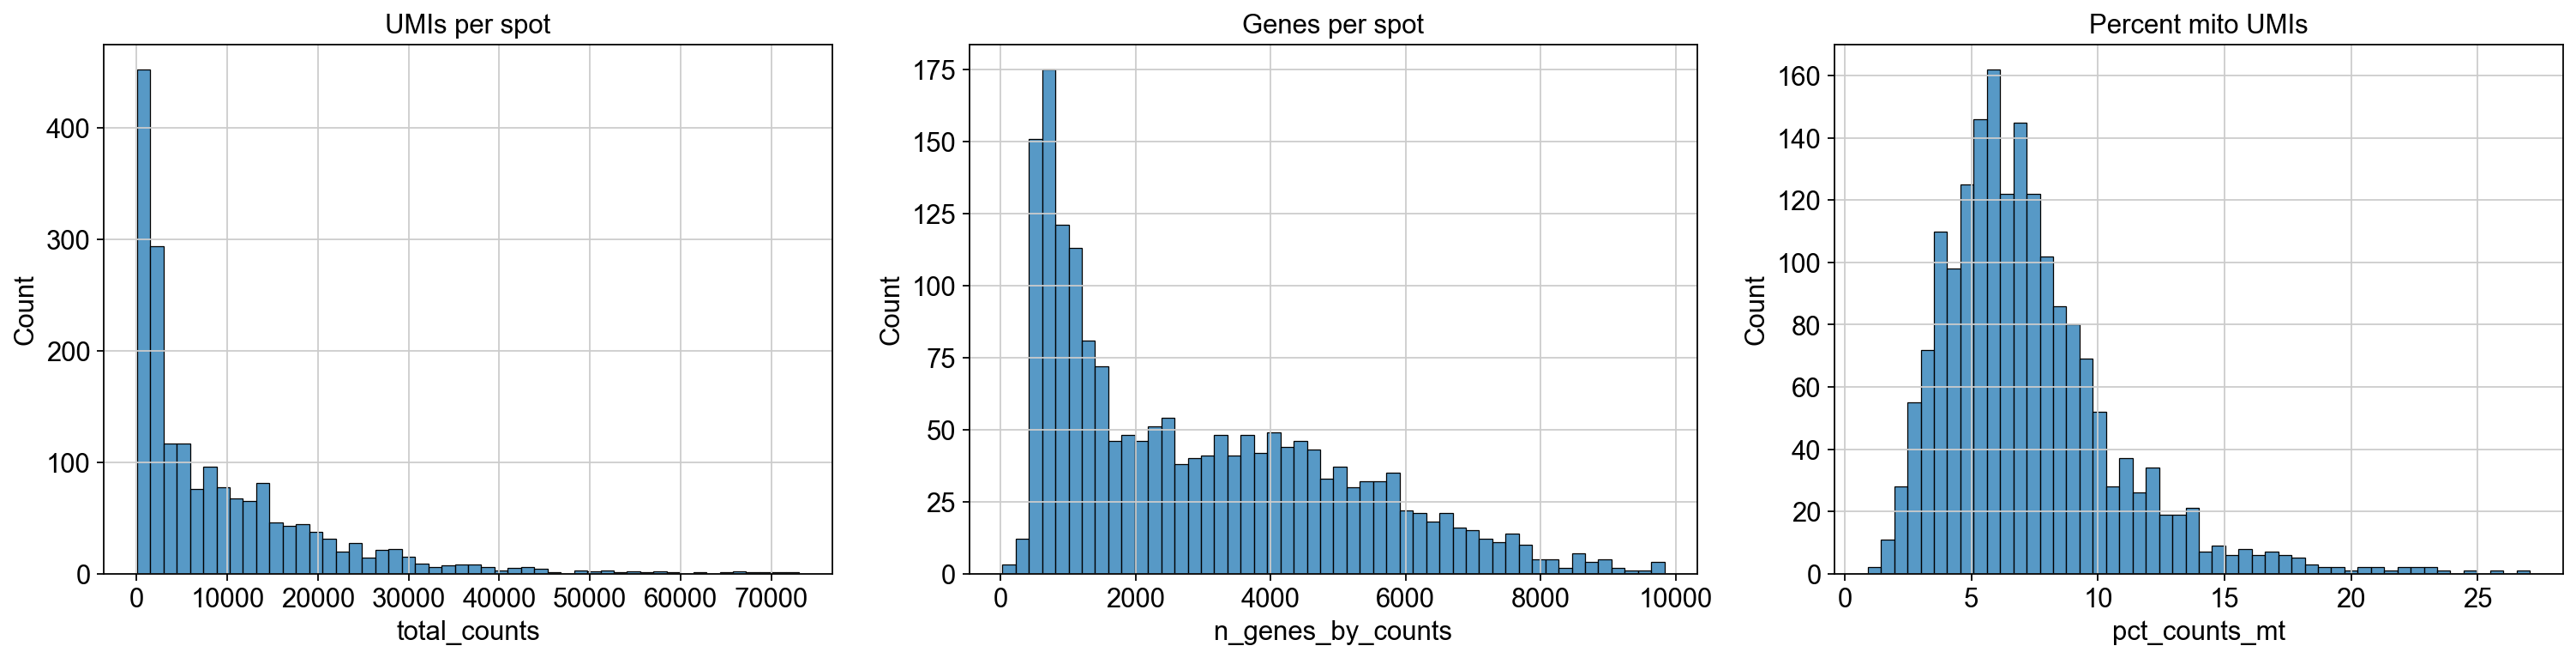

In [62]:
#  plot the three QC covariates n_genes_by_counts, total_counts and pct_counts_mt per sample

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(adata.obs["total_counts"], bins=50, kde=False, ax=axes[0])
axes[0].set_title("UMIs per spot")

sns.histplot(adata.obs["n_genes_by_counts"], bins=50, kde=False, ax=axes[1])
axes[1].set_title("Genes per spot")

sns.histplot(adata.obs["pct_counts_mt"], bins=50, kde=False, ax=axes[2])
axes[2].set_title("Percent mito UMIs")

plt.tight_layout()
plt.show()

In [ ]:
# select QC threshold for library size
adata.obs["qc_lib_size"] = adata.obs["total_counts"] < 500
adata.obs.qc_lib_size.value_counts()

qc_lib_size
False    1838
True       10
Name: count, dtype: int64

In [ ]:
# select QC threshold for detected features
adata.obs["qc_detected"] = adata.obs["n_genes_by_counts"] < 400
adata.obs.qc_detected.value_counts()

qc_detected
False    1838
True       10
Name: count, dtype: int64

In [ ]:
# select QC threshold for mito proportion
adata.obs["qc_mito_prop"] = adata.obs["pct_counts_mt"] > 20
adata.obs.qc_mito_prop.value_counts()

qc_mito_prop
False    1833
True       15
Name: count, dtype: int64

C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\3836548952.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\3836548952.py:14: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\3836548952.py:25: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


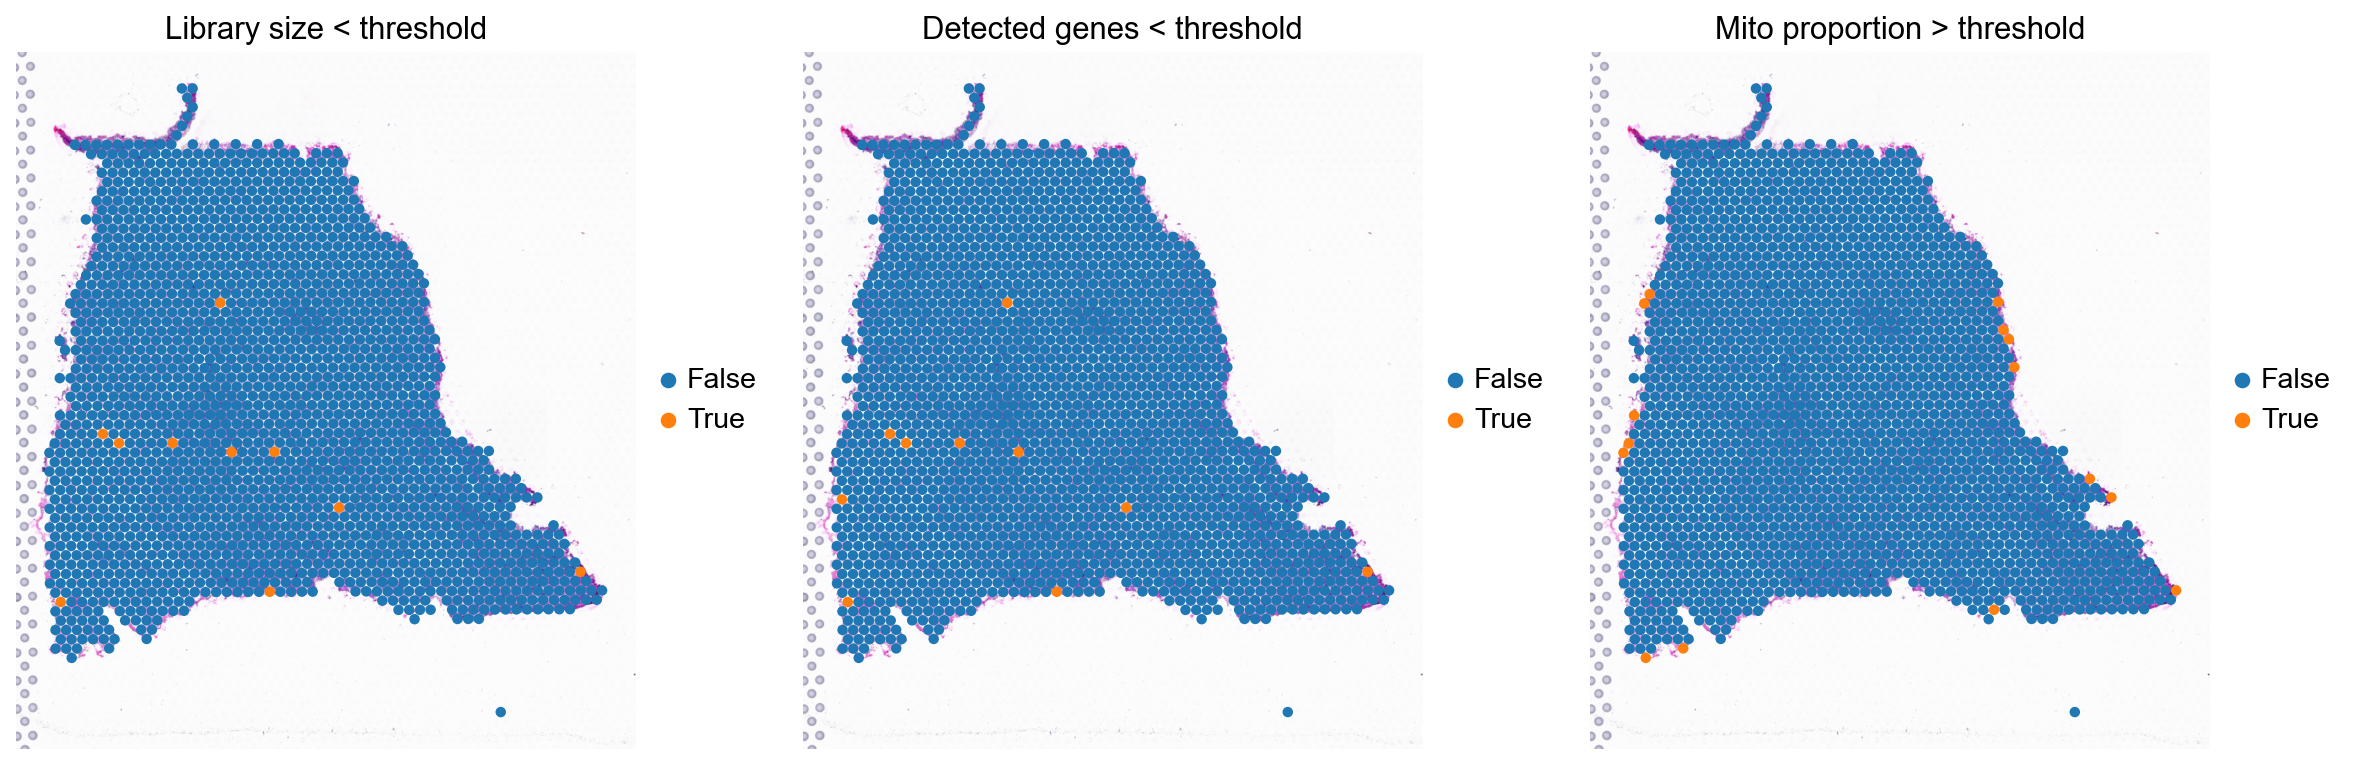

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sc.pl.spatial(
    adata,
    color="qc_lib_size",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Library size < threshold",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="qc_detected",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Detected genes < threshold",
    ax=axes[1],
    show=False
)

sc.pl.spatial(
    adata,
    color="qc_mito_prop",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Mito proportion > threshold",
    ax=axes[2],
    show=False
)

plt.tight_layout()
plt.show()

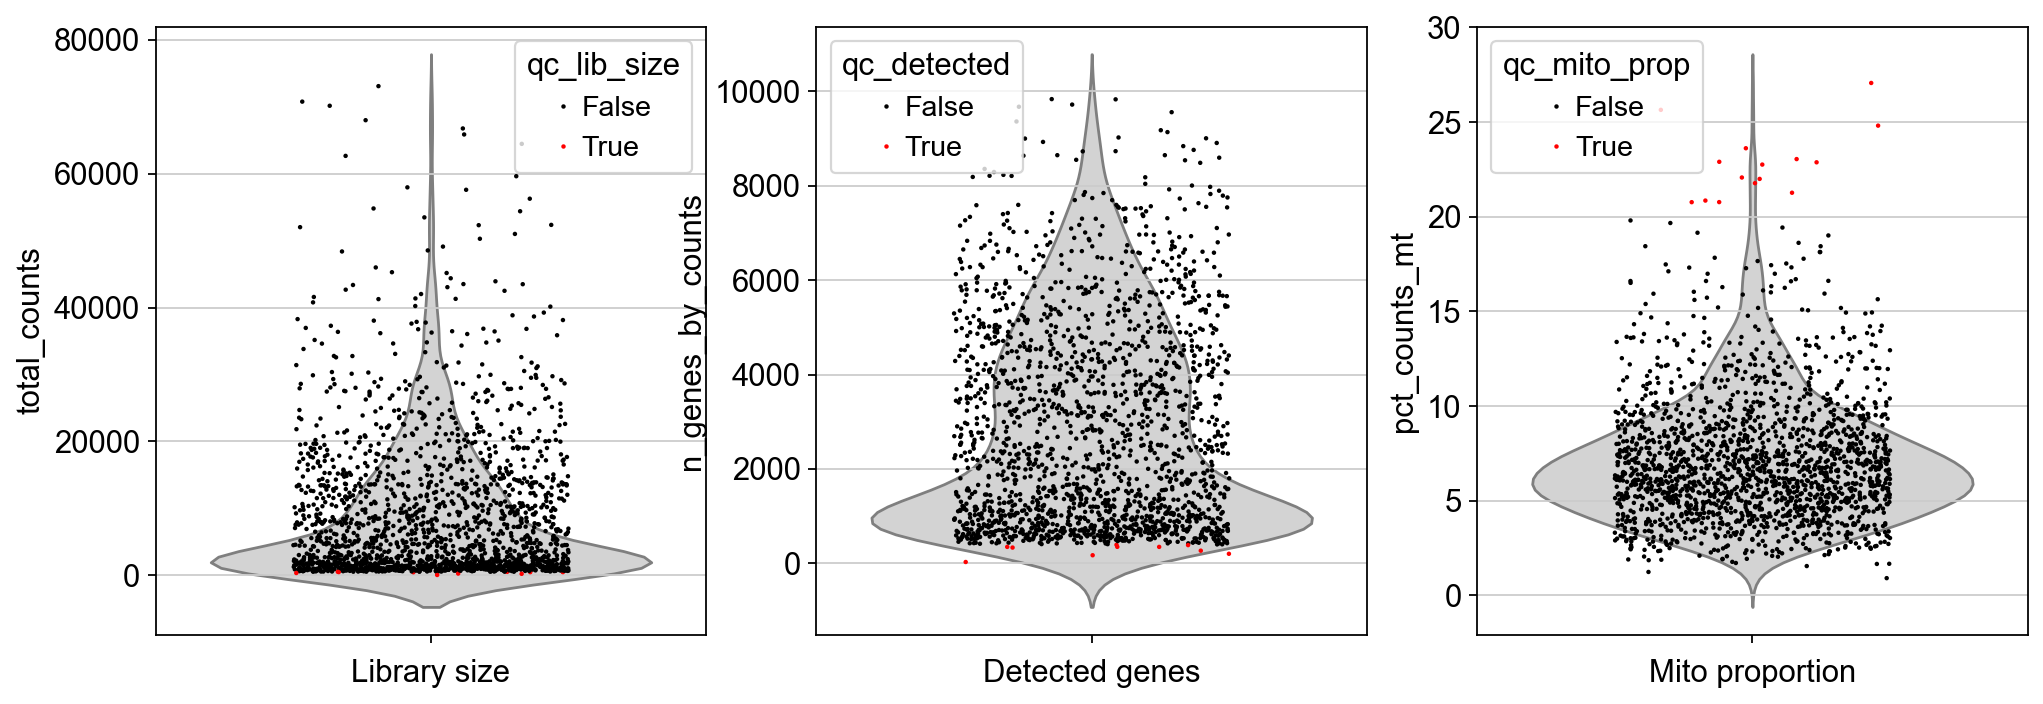

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.violinplot(y='total_counts', data=adata.obs, inner=None, color='lightgray', ax=axes[0])  # violin
sns.stripplot(y='total_counts', data=adata.obs, hue='qc_lib_size', 
              palette={True: 'red', False: 'black'}, size=2, jitter=0.25, dodge=False, ax=axes[0])
axes[0].set_xlabel('Library size')

sns.violinplot(y='n_genes_by_counts', data=adata.obs, inner=None, color='lightgray', ax=axes[1])  # violin
sns.stripplot(y='n_genes_by_counts', data=adata.obs, hue='qc_detected', 
              palette={True: 'red', False: 'black'}, size=2, jitter=0.25, dodge=False, ax=axes[1])
axes[1].set_xlabel('Detected genes')

sns.violinplot(y='pct_counts_mt', data=adata.obs, inner=None, color='lightgray', ax=axes[2])  # violin
sns.stripplot(y='pct_counts_mt', data=adata.obs, hue='qc_mito_prop', 
              palette={True: 'red', False: 'black'}, size=2, jitter=0.25, dodge=False, ax=axes[2])
axes[2].set_xlabel('Mito proportion')

plt.show()

## 9.4 Local outlier detection

One of the key assumptions of global outlier detection in single cell and spatial transcriptomics is that the QC metrics are independent of natural biology. Otherwise, cell or spots with naturally low library size or higher mitochondrial ratio will be more likely to be removed as outliers.

In [69]:
from scipy.spatial import cKDTree
from typing import Literal
import pandas as pd

def modified_z_score(values, s=1.4826):
    """
    Compute modified z-scores as in the R `spatialEco::outliers` function.
    Median Absolute Deviation (MAD) based robust z-score.
    """
    values = np.array(values, dtype=float)

    median_val = np.median(values)
    mad_val = np.median(np.abs(values - median_val))
    if mad_val == 0:
        return np.zeros_like(values)
    return 0.6745 * (values - median_val) / mad_val


def local_outliers(
    adata,
    metric: str = "n_genes_by_counts",
    direction: Literal["lower", "higher"] = "lower",
    n_neighbors: int = 36,
    samples: str = "Sample_ID",
    cutoff: float = 3
):
    """
    Detect local outliers in spatial transcriptomics data.

    Parameters
    ----------
    adata : AnnData
        AnnData object with `obsm['spatial']` and QC metric in `obs`.
    metric : str
        Column in adata.obs to use for outlier detection.
    direction : {"lower", "higher"}
        Whether to detect low or high outliers.
    n_neighbors : int
        Number of nearest neighbors to consider.
    samples : str
        Column in adata.obs containing sample IDs (batch).
    cutoff : float
        Modified z-score threshold for calling outliers.

    Returns
    -------
    AnnData
        Updated AnnData with new columns:
        - `<metric>_z`: modified z-scores
        - `<metric>_outliers`: boolean array for detected outliers
    """
    # Loop through each unique sample IDs
    all_results = []
    for sample_id in adata.obs[samples].unique():
        # Subset the data for the current sample
        subset = adata.obs[samples] == sample_id
        adata_sub = adata[subset].copy()

        # Create a list of spatial coordinates and qc features
        coords = np.array(adata_sub.obsm["spatial"])
        values = adata_sub.obs[metric].values

         # Find nearest neighbors (excluding self)
        tree = cKDTree(coords)
        _, idx = tree.query(coords, k=n_neighbors + 1)
        idx = idx[:, 1:]  # remove self from neighbor list
        
        # idx[i, j] = index of the j-th nearest neighbor of spot i
        
        # get neighborhood metrics (including self) for each spot
        z_scores = []
        for i in range(idx.shape[0]):
            neighbor_vals = values[np.concatenate(([i], idx[i]))]
            z = modified_z_score(neighbor_vals)[0]  # score for the central spot
            z_scores.append(z)
        
        # find outliers based on cutoff, store in outlier_flags
        z_scores = np.array(z_scores)
        outlier_flags = np.zeros_like(z_scores, dtype=bool)

        if direction == "higher":
            outlier_flags = z_scores > cutoff
        elif direction == "lower":
            outlier_flags = z_scores < -cutoff

        # save z-scores and outliers
        result_df = pd.DataFrame({
            f"{metric}_z": z_scores,
            f"{metric}_outliers": outlier_flags
        }, index=adata_sub.obs.index)

        all_results.append(result_df)
        
    # Merge results into main AnnData.obs
    results_df = pd.concat(all_results)
    adata.obs = adata.obs.join(results_df)

    return adata

local_outliers(adata)


AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'qc_li

In [70]:
# library size
local_outliers(adata, "log1p_total_counts", "lower")

# unique genes
local_outliers(adata, "log1p_n_genes_by_counts", "lower")

# mitochondrial percent
local_outliers(adata, "pct_counts_mt", "higher")

AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'qc_li

C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\2984849836.py:7: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\2984849836.py:18: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\2984849836.py:30: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\2984849836.py:41: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\2984849836.py:52: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\2984849836.py:63: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


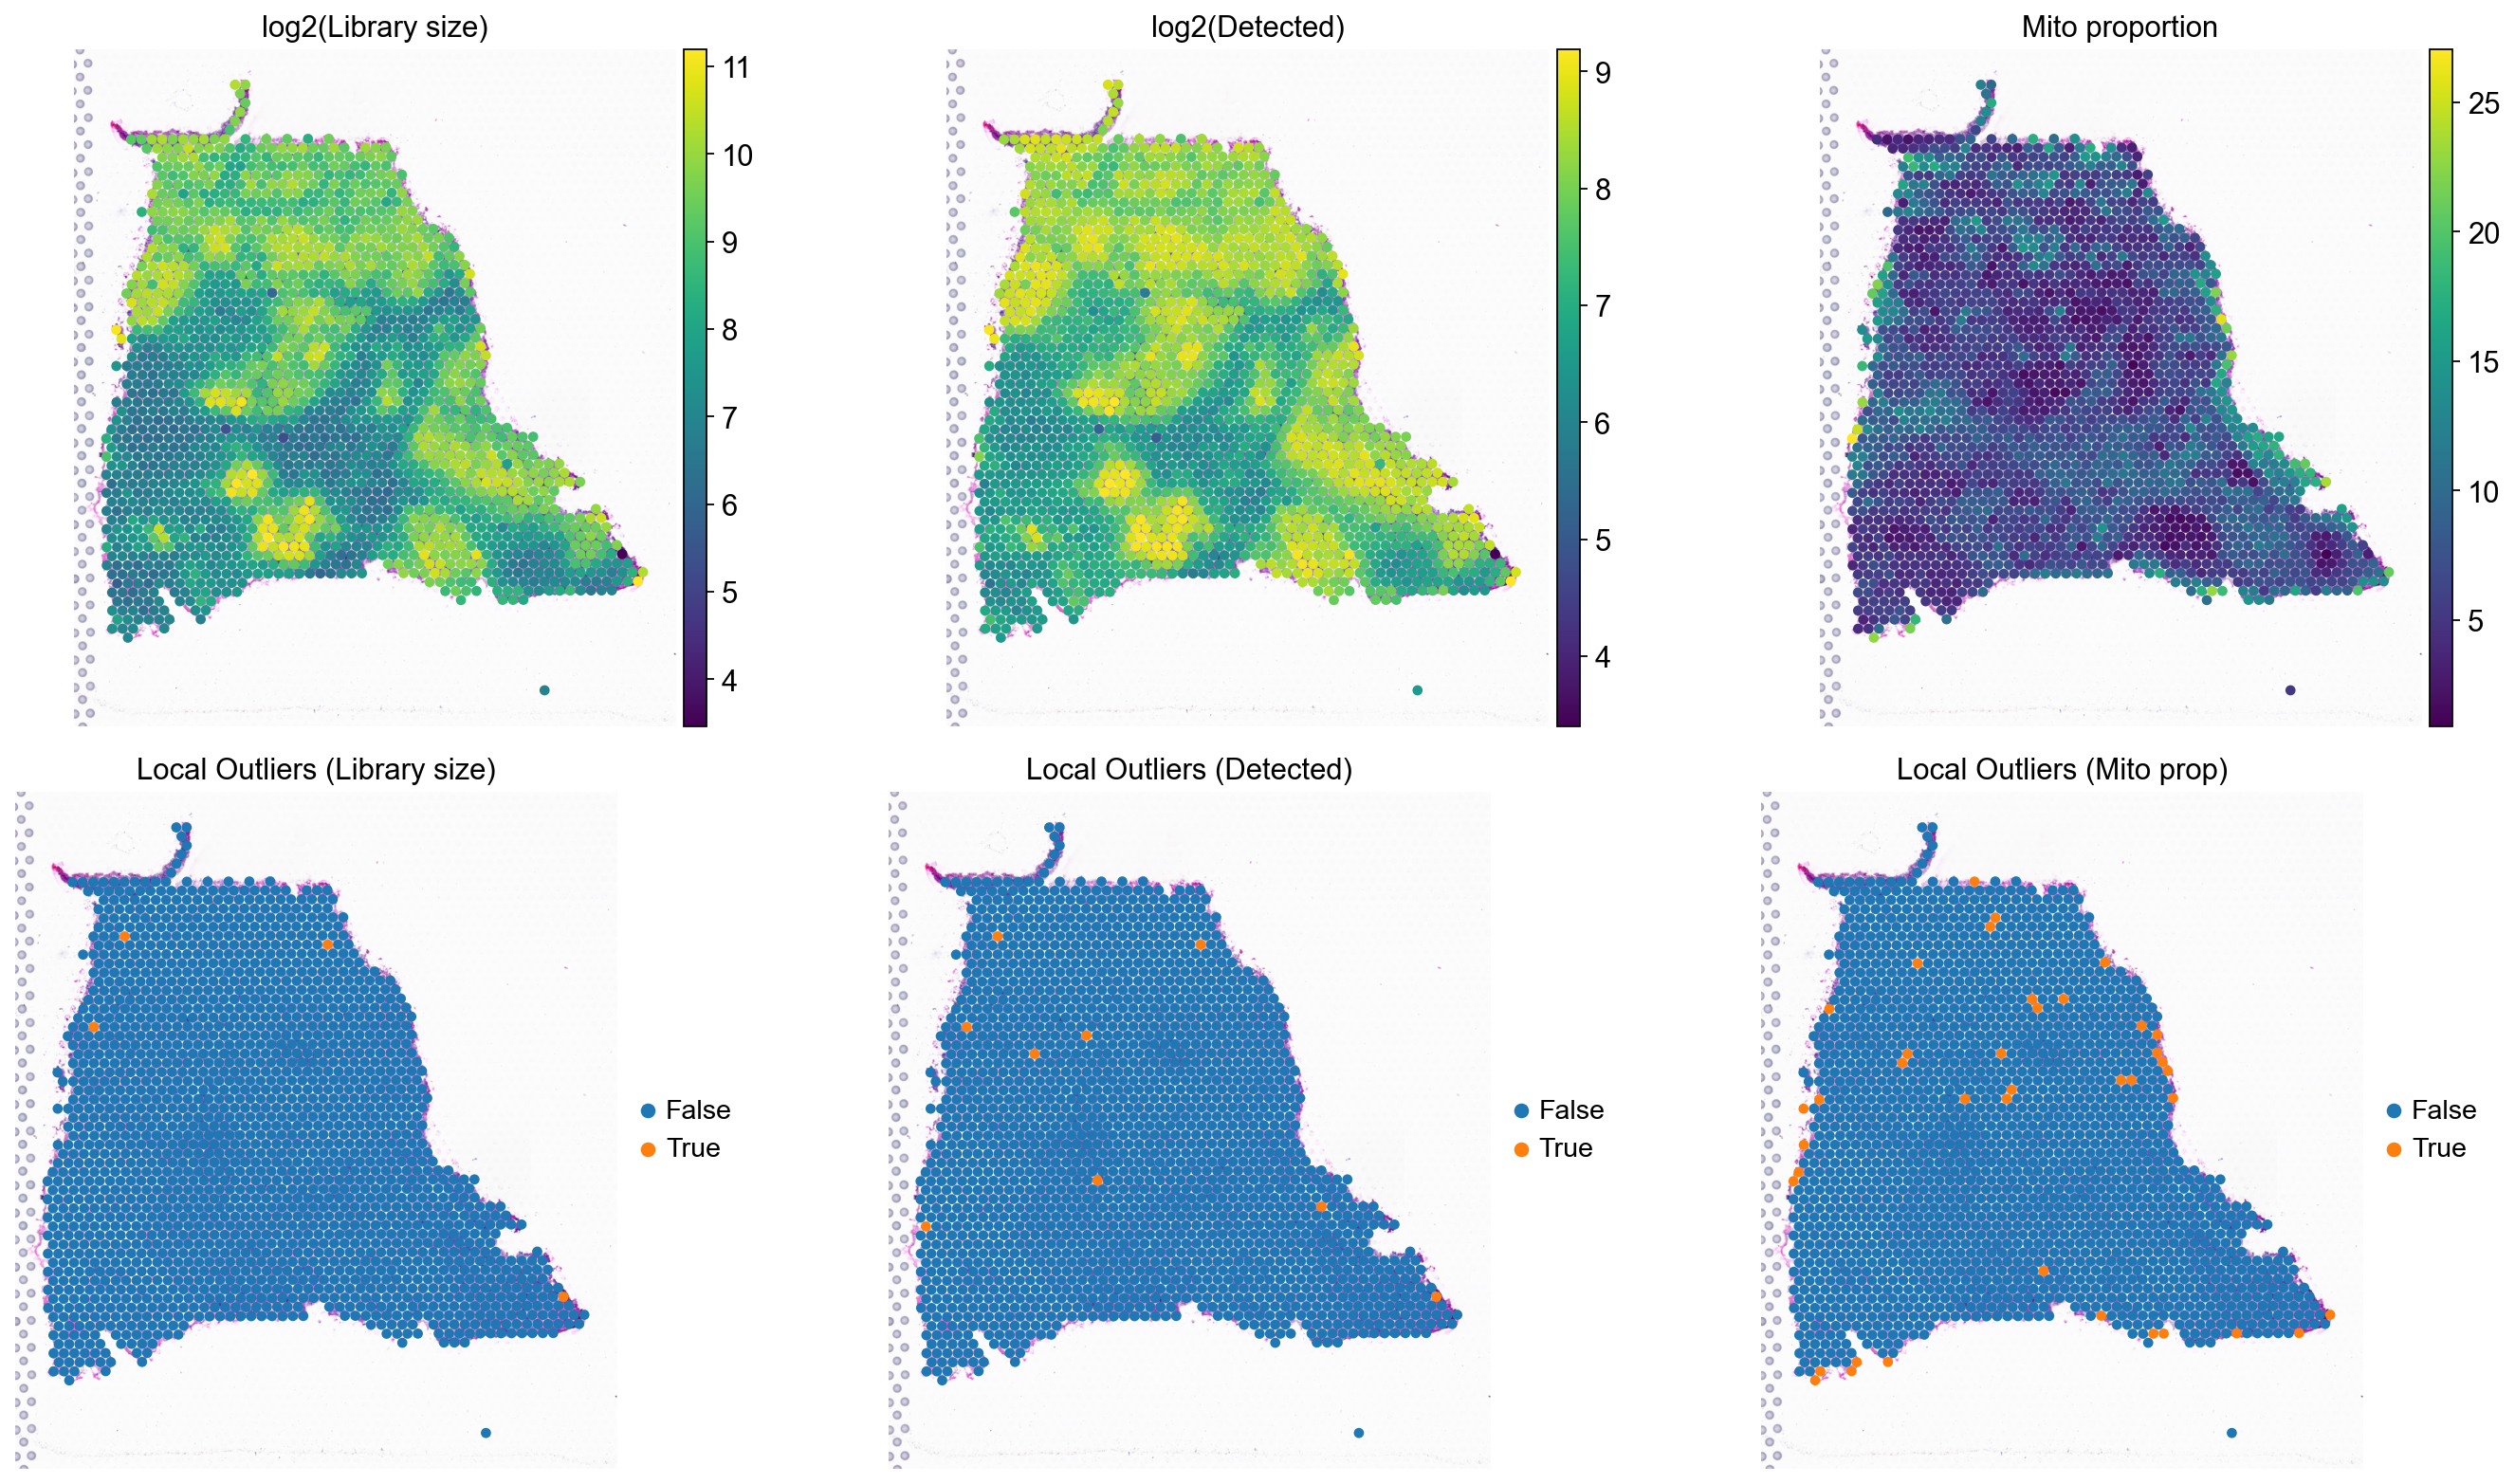

In [71]:
# Create 2 rows × 3 columns of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Flatten the axes array to index it linearly
axes = axes.flatten()

sc.pl.spatial(
    adata,
    color="log1p_total_counts",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="log2(Library size)",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="log1p_total_counts_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers (Library size)",
    ax=axes[3],
    show=False
)


sc.pl.spatial(
    adata,
    color="log1p_n_genes_by_counts",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="log2(Detected)",
    ax=axes[1],
    show=False
)

sc.pl.spatial(
    adata,
    color="log1p_n_genes_by_counts_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers (Detected)",
    ax=axes[4],
    show=False
)

sc.pl.spatial(
    adata,
    color="pct_counts_mt",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Mito proportion",
    ax=axes[2],
    show=False
)

sc.pl.spatial(
    adata,
    color="pct_counts_mt_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers (Mito prop)",
    ax=axes[5],
    show=False
)

plt.tight_layout()
plt.show()

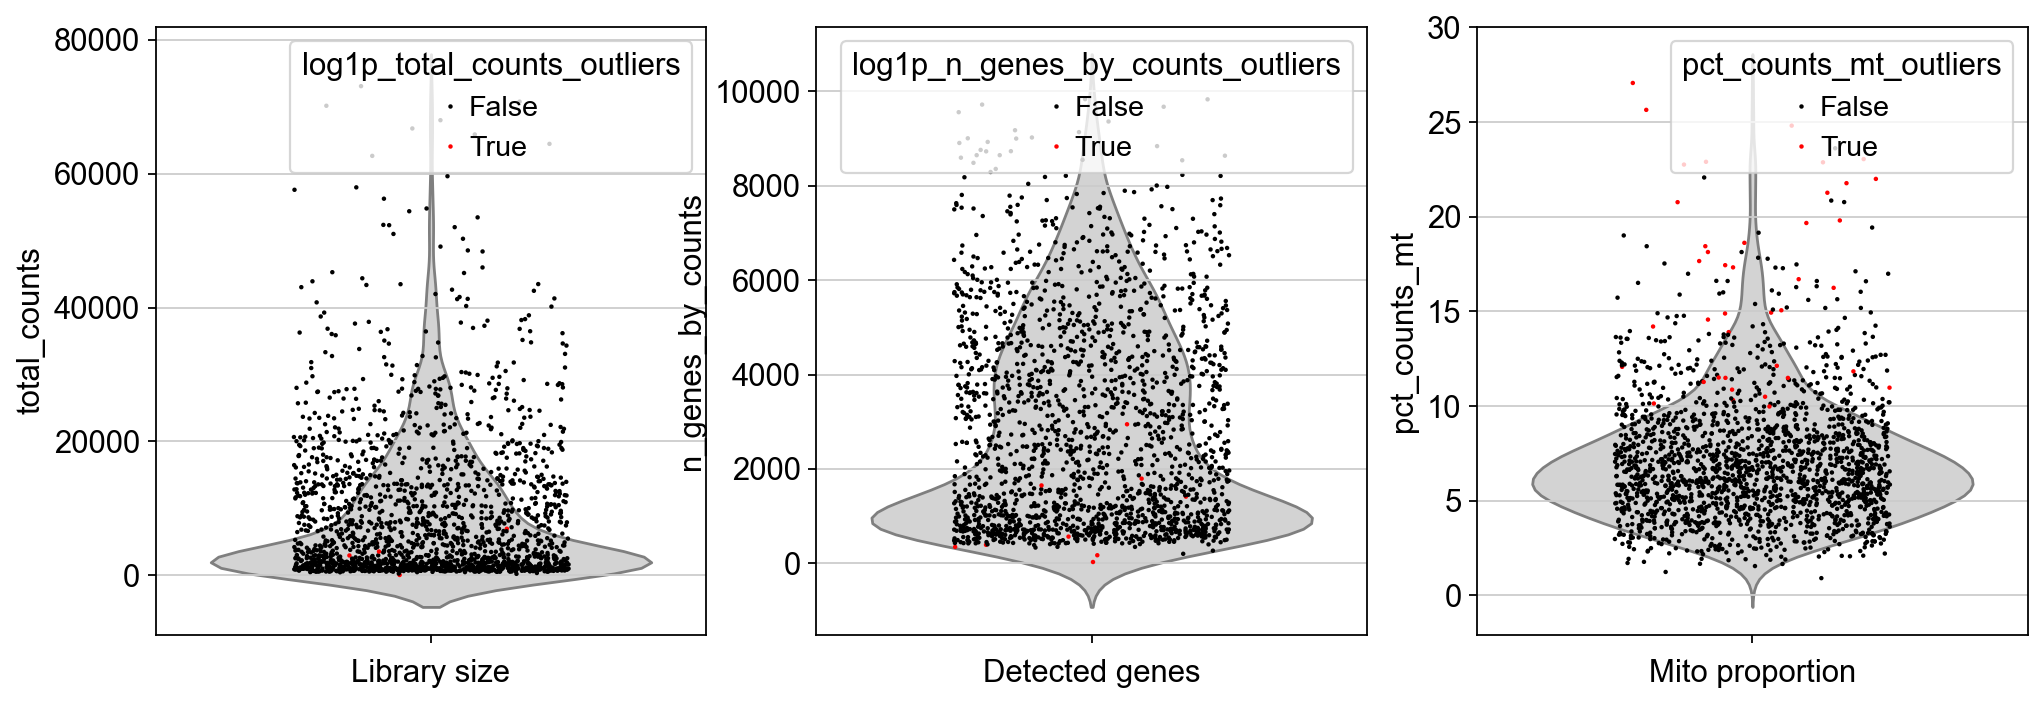

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.violinplot(y='total_counts', data=adata.obs, inner=None, color='lightgray', ax=axes[0])  # violin
sns.stripplot(y='total_counts', data=adata.obs, hue='log1p_total_counts_outliers', 
              palette={True: 'red', False: 'black'}, size=2, jitter=0.25, dodge=False, ax=axes[0])
axes[0].set_xlabel('Library size')

sns.violinplot(y='n_genes_by_counts', data=adata.obs, inner=None, color='lightgray', ax=axes[1])  # violin
sns.stripplot(y='n_genes_by_counts', data=adata.obs, hue='log1p_n_genes_by_counts_outliers', 
              palette={True: 'red', False: 'black'}, size=2, jitter=0.25, dodge=False, ax=axes[1])
axes[1].set_xlabel('Detected genes')

sns.violinplot(y='pct_counts_mt', data=adata.obs, inner=None, color='lightgray', ax=axes[2])  # violin
sns.stripplot(y='pct_counts_mt', data=adata.obs, hue='pct_counts_mt_outliers', 
              palette={True: 'red', False: 'black'}, size=2, jitter=0.25, dodge=False, ax=axes[2])
axes[2].set_xlabel('Mito proportion')

plt.show()

## 9.5 Remove low-quality spots

In [73]:
# combine global outliers
adata.obs["global_outliers"] = (adata.obs["qc_lib_size"].values) | (adata.obs["qc_detected"].values) | (adata.obs["qc_mito_prop"].values)
adata.obs.global_outliers.value_counts()

global_outliers
False    1822
True       26
Name: count, dtype: int64

In [74]:
# combine local outliers
adata.obs["local_outliers"] = (adata.obs["log1p_total_counts_outliers"].values) | (adata.obs["log1p_n_genes_by_counts_outliers"].values) | (adata.obs["pct_counts_mt_outliers"].values)
adata.obs.local_outliers.value_counts()

local_outliers
False    1800
True       48
Name: count, dtype: int64

C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\4050174888.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
C:\Users\rebec\AppData\Local\Temp\ipykernel_6992\4050174888.py:15: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


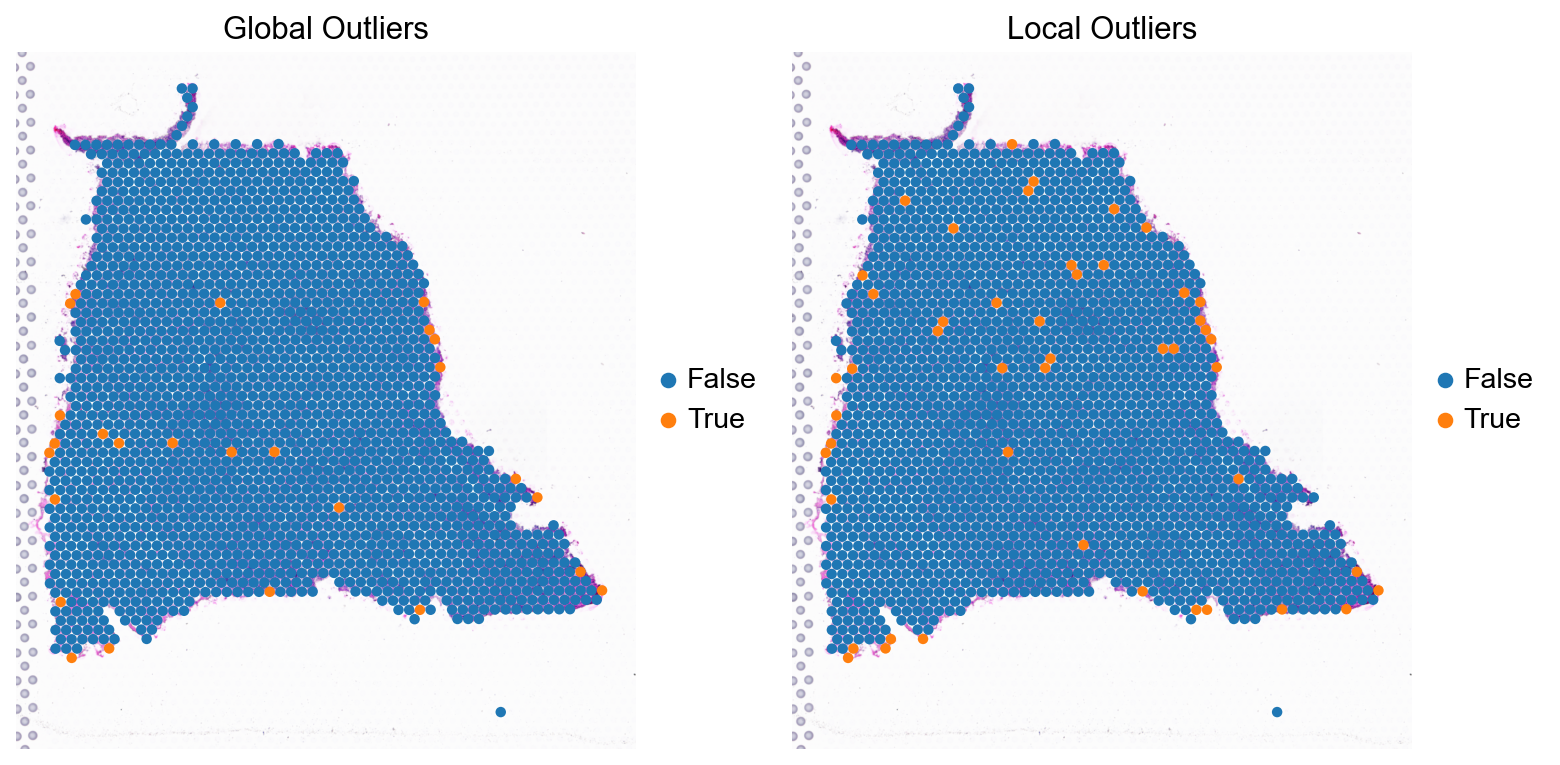

In [75]:
# Create a row of 3 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

sc.pl.spatial(
    adata,
    color="global_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Global Outliers",
    ax=axes[0],
    show=False
)

sc.pl.spatial(
    adata,
    color="local_outliers",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Local Outliers",
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [76]:
# combine local and global outliers and store in 'discard' column
adata.obs["discard"] = (adata.obs["global_outliers"].values) | (adata.obs["local_outliers"].values)

# remove combined set of low-quality spots
adata = adata[adata.obs["discard"] == False, :]

# remove features with all 0 counts
sc.pp.filter_genes(adata, min_counts=1)

adata

c:\Users\rebec\miniforge3\envs\spatial\lib\site-packages\scanpy\preprocessing\_simple.py:291: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_counts"] = number


AnnData object with n_obs × n_vars = 1789 × 23336
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'qc_li

## 9.6 Advanced topics

### 9.6.1 Histological artifact detection

When working with ST datasets, ensuring high-quality data is essential for accurate downstream analyses. One common issue researchers face is the presence of technical artifacts. Here, we will demonstrate how to detect and remove “hangnail” artifacts from Visium datasets.

Hangnails artifacts arise during tissue preparation, and most commonly occur when smaller areas, such as distinct brain regions, are dissected from larger structures like whole human brain sections Totty, Hicks, and Guo (2025)
Totty, Michael, Stephanie C. Hicks, and Boyi Guo. 2025. “SpotSweeper: Spatially Aware Quality Control for Spatial Transcriptomics.” Nature Methods 22: 1520–30. https://doi.org/10.1038/s41592-025-02713-3.
.

In [20]:
# Build neighbors from spatial coords
sc.pp.neighbors(adata, n_neighbors=36, use_rep="spatial")

metric = adata.obs["pct_counts_mt"].values
neighbors = adata.obsp["connectivities"]

local_var = []
for i in range(neighbors.shape[0]):
    neigh_idx = neighbors[i].nonzero()[1]
    neigh_vals = metric[neigh_idx]
    local_var.append(np.var(neigh_vals, ddof=1))

adata.obs["local_mito_variance_k36"] = local_var

c:\Users\rebec\miniforge3\envs\spatial\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


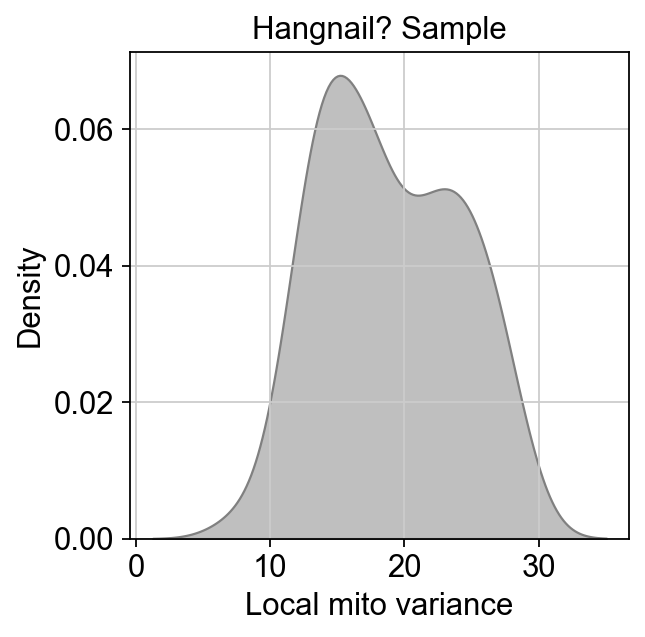

In [21]:
sns.kdeplot(
    data=adata.obs,
    x="local_mito_variance_k36",  # column name from earlier step
    fill=True,
    color="gray",
    alpha=0.5
)

plt.title("Hangnail? Sample")
plt.xlabel("Local mito variance")
plt.ylabel("Density")
plt.show()

Samples affected by hangnails often exhibit a long-tailed or bimodal distribution towards lower variance, reflecting regions with abnormal mitochondrial signal variation.

In [22]:
import squidpy as sq

# Step 1 — build spatial neighbors
sq.gr.spatial_neighbors(adata, coord_type="grid")  # hexagonal possible for Visium

# Step 2 — smooth mitochondrial proportion over neighbors
metric = adata.obs["expr_chrM_ratio"].values
smoothed_metric = sq.gr.spatial_smooth(adata, values=metric, n_neighs=7)

# Step 3 — find artifacts (e.g., above threshold)
threshold = np.mean(smoothed_metric) + 2 * np.std(smoothed_metric)
adata.obs["artifact"] = smoothed_metric > threshold

# Step 4 — plot spots colored by artifact flag
sc.pl.spatial(
    adata,
    color="artifact",
    library_id="GSM6592049_M2",  # your Visium sample ID
    size=1.5,
    cmap=["lightgray", "red"],
    title="Detected Artifacts"
)

c:\Users\rebec\miniforge3\envs\spatial\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\rebec\miniforge3\envs\spatial\lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
c:\Users\rebec\miniforge3\envs\spatial\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


KeyError: 'expr_chrM_ratio'

### 9.6.2 Assessing spot quality via cell segmentation

### 9.6.3 Zero-cell and single-cell spots

not possible, because for our data we don't have information about the number of cells per spot

In [ ]:
haha = ["GSM6592049_M2.h5ad", "GSM6592052_M5.h5ad", "GSM6592053_M6.h5ad", "GSM6592055_M8.h5ad", "GSM6592059_M13.h5ad", "output-XETG00125_compact.h5ad"]

for h in haha:
    adata_temp = sc.read_h5ad(os.path.join("..", "datasets", h))
    adata_temp.var_names_make_unique()
    print(h)
    print(adata_temp.obs.columns)

GSM6592049_M2.h5ad
Index(['in_tissue', 'array_row', 'array_col', 'suspension_type',
       'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id',
       'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation',
       'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid',
       'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation',
       'cell_type_ontology_term_id', 'is_primary_data', 'treatment',
       'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex',
       'tissue', 'self_reported_ethnicity', 'development_stage',
       'observation_joinid'],
      dtype='object')
GSM6592052_M5.h5ad
Index(['in_tissue', 'array_row', 'array_col', 'suspension_type',
       'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontolog

# 10 Intermediate Processing

## 10.1 Preamble

This chapter demonstrates methods for several data processing steps – normalization, feature selection, and dimensionality reduction – that are required before downstream analysis methods can be applied.

## 10.2 Normalization

### 10.2.1 Library size normalization

A simple and fast approach for normalization is “library size normalization”, which consists of calculating log-transformed normalized counts (“logcounts”) using library size factors, treating each spot as equivalent to a single cell. This method is simple, fast, and generally provides a good baseline.

However, library size normalization does not make use of any spatial information. In some datasets, the simplified assumption that each spot can be treated as equivalent to a single cell is not appropriate, and can create problems during analysis. (“Library size confounds biology in spatial transcriptomics data” (Bhuva et al. 2024).)

Some alternative non-spatial methods from scRNA-seq workflows (e.g. normalization by deconvolution) are also less appropriate for spot-based ST data, since spots can contain multiple cells from one or more cell types, and datasets can contain multiple samples (e.g. multiple tissue sections), which may result in sample-specific clustering.

In [ ]:
# Compute library size normalization
sc.pp.normalize_total(adata, target_sum=1e4, inplace=True)

## 10.3 Feature selection
### 10.3.1 Highly variable genes (HVGs)

Identifying a set of top “highly variable genes” (HVGs) is a standard step for feature selection in many scRNA-seq workflows, which can also be used as a simple and fast baseline approach in spot-based ST data. This makes the simplified assumption that spots can be treated as equivalent to cells.